# 分块 Burg vs 递归 Burg（RLS 化）LPC 分析对比

比较传统分块 Burg 法与逐样本递推 Burg 法（递归最小二乘风格）的 LPC 分析效果。

**音频**：`wormhole.wav` 前 0.2 秒  
**对比内容**：残差波形、LPC 包络（频率响应）、反射系数演化

### 递归 Burg 公式回顾

第 $m$ 级格型滤波器的递归更新：

$$
\begin{aligned}
A_m(t) &= \lambda \, A_m(t-1) + f_{m-1}[t] \, b_{m-1}[t-1] \\
B_m(t) &= \lambda \, B_m(t-1) + f_{m-1}[t]^2 + b_{m-1}[t-1]^2 \\
k_m(t) &= -2 \, A_m(t) \, / \, B_m(t)
\end{aligned}
$$

### 遗忘系数与遗忘时间

遗忘系数 $\lambda$ 由遗忘时间 $\tau$（秒）通过一阶指数平滑公式确定：

$$
\lambda = \exp\!\left(-\frac{1}{\tau \cdot f_s}\right)
$$

- $\tau$ 越大 → $\lambda \to 1$ → 记忆越长，递归解越接近分块解
- $\tau$ 越小 → $\lambda$ 越小 → 自适应越快，但估计方差越大

等效记忆长度（采样点）：$L_{\text{eff}} \approx \dfrac{1}{1 - \lambda}$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import soundfile as sf
from scipy.signal import freqz
from IPython.display import Audio
import os

# matplotlib 中文字体配置
plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei"]
plt.rcParams["axes.unicode_minus"] = False

# 音频路径 — qwqdsp tests work_dir
WORK_DIR = r"c:\Users\Kawai\Desktop\a5632645\qwqdsp\qwqdsp\tests\work_dir"
AUDIO_PATH = os.path.join(WORK_DIR, "input", "wormhole.wav")

print(f"音频路径: {AUDIO_PATH}")
print(f"文件存在: {os.path.exists(AUDIO_PATH)}")

音频路径: c:\Users\Kawai\Desktop\a5632645\qwqdsp\qwqdsp\tests\work_dir\input\wormhole.wav
文件存在: True


In [2]:
# ------------------------------------------------------------
# 读取音频并截取前 0.2 秒
# ------------------------------------------------------------
x_full, fs = sf.read(AUDIO_PATH)

# 转为单声道（若立体声则取左声道）
if x_full.ndim > 1:
    x_full = x_full[:, 0]

duration = 0.2  # 秒
num_samples = int(duration * fs)
x = x_full[:num_samples].copy()

print(f"采样率: {fs} Hz")
print(f"截取长度: {num_samples} 样本 ({duration} 秒)")
print(f"信号范围: [{x.min():.4f}, {x.max():.4f}]")

# 预加重
pre_emph = 0.97
x_pre = np.append(x[0], x[1:] - pre_emph * x[:-1])

t = np.arange(len(x)) / fs

采样率: 48000 Hz
截取长度: 9600 样本 (0.2 秒)
信号范围: [-0.5369, 0.3554]


In [3]:
# ------------------------------------------------------------
# 传统分块 Burg 法
# ------------------------------------------------------------
def block_burg(x, order):
    """
    标准分块 Burg 法：最小化前后向预测误差能量和，一次处理整帧。

    参数:
        x: 输入信号 (N,)
        order: LPC 阶数 P
    返回:
        a: LPC 系数 [1, a1, a2, ..., aP]  (P+1,)
        e: 残差信号 (N,)
        k: 反射系数 (order,)
    """
    N = len(x)
    # 前后向误差初始化
    f = x.copy().astype(np.float64)
    b = x.copy().astype(np.float64)
    k = np.zeros(order)
    a = np.array([1.0])

    for m in range(order):
        # 计算分子分母：第 m 阶反射系数
        num = 2.0 * np.sum(f[m+1:] * b[m:N-1])
        den = np.sum(f[m+1:]**2 + b[m:N-1]**2)
        if den < 1e-30:
            k[m] = 0.0
        else:
            k[m] = -num / den

        # 更新前后向误差
        f_next = f.copy()
        b_next = b.copy()
        # f_m[n] = f_{m-1}[n] + k_m * b_{m-1}[n-1]
        f_next[m+1:] = f[m+1:] + k[m] * b[m:N-1]
        # b_m[n] = b_{m-1}[n-1] + k_m * f_{m-1}[n]
        b_next[m+1:] = b[m:N-1] + k[m] * f[m+1:]

        f, b = f_next, b_next

        # Levinson 递推：反射系数 -> LPC 系数
        a = np.pad(a, (0, 1), mode='constant')
        # a_{m}(i) = a_{m-1}(i) + k_m * a_{m-1}(m-i)
        for i in range(1, m + 1):
            a[i] += k[m] * a[m - i]

    # 残差 = 最终前向误差
    e = f.copy()
    return a, e, k

In [4]:
# ------------------------------------------------------------
# 递归 Burg 法（RLS 化）
# ------------------------------------------------------------
def recursive_burg(x, order, lam=0.995, eps=1e-6):
    """
    递归 Burg 法：每采样点递推更新累积量 A_m(t)、B_m(t)，
    逐样本计算反射系数。

    公式（第 m 级）：
        A_m(t) = λ·A_m(t-1) + f_{m-1}[t]·b_{m-1}[t-1]
        B_m(t) = λ·B_m(t-1) + f_{m-1}[t]² + b_{m-1}[t-1]²
        k_m(t) = -2·A_m(t) / B_m(t)

    参数:
        x: 输入信号 (N,)
        order: LPC 阶数 P
        lam: 遗忘因子 λ（0 < λ ≤ 1）
        eps: 分母初始化小常数
    返回:
        a: LPC 系数 [1, a1, ..., aP] (P+1,)
        e: 残差信号 (N,)
        k_history: 反射系数随时间演化 (N, order)
    """
    N = len(x)
    dtype = np.float64

    # 格型状态：f_curr[m] = f_{m-1}[t], b_prev_arr[m] = b_{m-1}[t-1]
    f_curr = np.zeros(order + 1, dtype=dtype)
    b_prev_arr = np.zeros(order + 1, dtype=dtype)  # 上一时刻的 b_{m-1}[t-1]
    b_curr = np.zeros(order + 1, dtype=dtype)      # 本时刻计算得到的 b_m[t]

    # 累积量
    A = np.zeros(order, dtype=dtype)
    B = np.full(order, eps, dtype=dtype)

    # 反射系数
    k = np.zeros(order, dtype=dtype)
    k_history = np.zeros((N, order), dtype=dtype)

    # 残差
    e = np.zeros(N, dtype=dtype)

    for t in range(N):
        # ---- 第 0 级 ----
        f_curr[0] = x[t]
        b_curr[0] = x[t]  # b_0[t] = x[t]

        # ---- 第 1..order 级 ----
        for m in range(order):
            # f_{m-1}[t] 和 b_{m-1}[t-1]
            f_m1_t = f_curr[m]
            b_m1_t1 = b_prev_arr[m]

            # 更新累积量
            A[m] = lam * A[m] + f_m1_t * b_m1_t1
            B[m] = lam * B[m] + f_m1_t**2 + b_m1_t1**2

            # 计算反射系数
            k[m] = -2.0 * A[m] / B[m] if B[m] > 1e-30 else 0.0
            k[m] = np.clip(k[m], -0.999, 0.999)

            # 格型传播
            f_curr[m + 1] = f_m1_t + k[m] * b_m1_t1   # f_m[t]
            b_curr[m + 1] = b_m1_t1 + k[m] * f_m1_t   # b_m[t]

        k_history[t] = k.copy()
        e[t] = f_curr[order]

        # ---- 为下一时刻准备 b_{m-1}[t-1] ----
        # 下一时刻的第 m 级需要 b_{m-1}[t]（当前时刻的 b_{m-1}）
        # 即 b_curr[0..order-1] -> b_prev_arr[0..order-1]
        b_prev_arr[:order] = b_curr[:order]

    # 从最终反射系数计算 LPC 系数（Levinson 递推）
    a_final = np.ones(order + 1, dtype=dtype)
    for m in range(order):
        k_m = k[m]
        a_prev = a_final.copy()
        a_final[m + 1] = k_m
        for i in range(1, m + 1):
            a_final[i] = a_prev[i] + k_m * a_prev[m - i + 1]

    return a_final, e, k_history

In [27]:
# ------------------------------------------------------------
# 运行两种 Burg 方法
# ------------------------------------------------------------
P = 16          # LPC 阶数

# 遗忘时间 → 遗忘系数（一阶指数平滑）
tau = 0.010    # 遗忘时间 (秒)，≈10ms 对应约 480 采样点的有效记忆
lam = np.exp(-1.0 / (tau * fs))
print(f"遗忘时间 τ = {tau*1000:.1f} ms")
print(f"遗忘系数 λ = {lam:.6f}  (等效记忆 ≈ {1/(1-lam):.0f} 采样点)")

# 分块 Burg（在预加重信号上计算）
a_block, e_block, k_block = block_burg(x_pre, P)

# 递归 Burg
a_rec, e_rec, k_history = recursive_burg(x_pre, P, lam=lam)

print(f"\n分块 Burg LPC 系数 ({P} 阶):")
print(np.array2string(a_block, precision=6, suppress_small=True))

print(f"\n递归 Burg LPC 系数 ({P} 阶, λ={lam:.4f}):")
print(np.array2string(a_rec, precision=6, suppress_small=True))

print(f"\n分块 Burg 反射系数:")
print(np.array2string(k_block, precision=6, suppress_small=True))

print(f"\n递归 Burg 最终反射系数:")
print(np.array2string(k_history[-1], precision=6, suppress_small=True))

# 残差标准化到 [-1, 1]
e_block_max = np.max(np.abs(e_block))
e_rec_max = np.max(np.abs(e_rec))
e_block_norm = e_block / e_block_max if e_block_max > 1e-30 else e_block
e_rec_norm = e_rec / e_rec_max if e_rec_max > 1e-30 else e_rec
print(f"\n残差归一化因子: 分块={e_block_max:.6e}, 递归={e_rec_max:.6e}")

遗忘时间 τ = 10.0 ms
遗忘系数 λ = 0.997919  (等效记忆 ≈ 481 采样点)

分块 Burg LPC 系数 (16 阶):
[ 1.       -2.603634  4.196162 -4.758055  2.463766  3.787362 -9.390042
 11.098983 -6.769695  1.267064  1.922002 -2.721281  2.003281 -0.986568
  0.263317 -0.056835  0.      ]

递归 Burg LPC 系数 (16 阶, λ=0.9979):
[ 1.       -2.431389  3.752008 -4.352954  3.084638 -0.995156 -0.902579
  1.571849 -0.757872 -0.495449  1.161834 -0.978513  0.174303  0.454202
 -0.541619  0.361519 -0.097053]

分块 Burg 反射系数:
[-0.62387   0.339756 -0.770223  0.635926 -0.431879  0.661777 -0.550001
  0.552856 -0.648621  0.434314 -0.466163  0.034075  0.112106 -0.448533
  0.11534  -0.056835]

递归 Burg 最终反射系数:
[-0.933021  0.07496  -0.872455  0.442774 -0.550366  0.62453  -0.365991
  0.207697  0.156184 -0.354673  0.138557  0.24191  -0.135338  0.12951
  0.126739 -0.097053]

残差归一化因子: 分块=1.353175e-02, 递归=2.325769e-02


In [28]:
# ------------------------------------------------------------
# 计算 LPC 包络（频率响应）
# ------------------------------------------------------------
def lpc_envelope(a, fs, n_fft=4096):
    """从 LPC 系数计算频谱包络（dB 单位）"""
    w, h = freqz(1.0, a, worN=n_fft, fs=fs)
    env_db = 20.0 * np.log10(np.abs(h) + 1e-30)
    return w, env_db

# 原始信号频谱（参考包络）
n_fft = 4096
w, h_raw = freqz(x_pre, worN=n_fft, fs=fs)
raw_spectrum_db = 20.0 * np.log10(np.abs(h_raw) + 1e-30)

# 两种方法的 LPC 包络
w_block, env_block_db = lpc_envelope(a_block, fs, n_fft)
w_rec, env_rec_db = lpc_envelope(a_rec, fs, n_fft)

print("LPC 包络计算完成")

LPC 包络计算完成


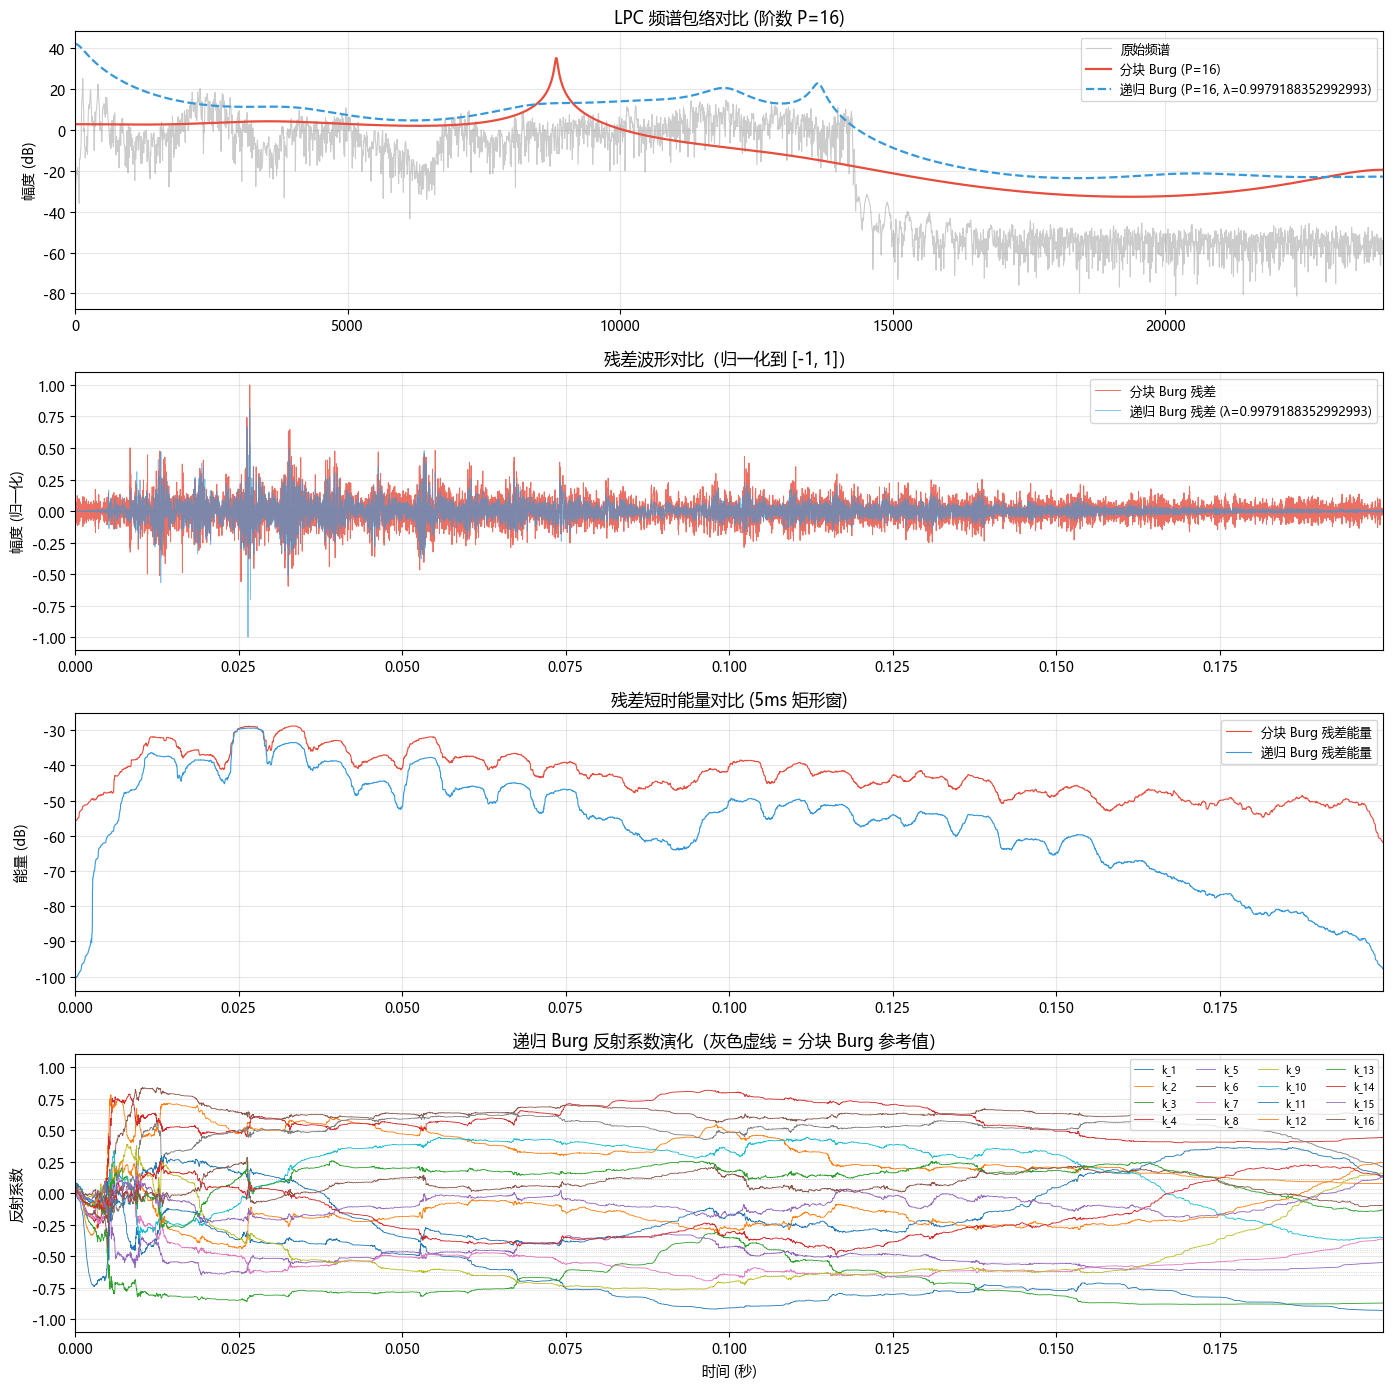

In [29]:
# ------------------------------------------------------------
# 绘图对比
# ------------------------------------------------------------
fig, axes = plt.subplots(4, 1, figsize=(14, 14))

# ===== 子图 1: 原始波形 + LPC 包络（频谱） =====
ax1 = axes[0]
ax1.plot(w, raw_spectrum_db, color='gray', alpha=0.4, linewidth=0.8, label='原始频谱')
ax1.plot(w_block, env_block_db, color='#e74c3c', linewidth=1.6, label=f'分块 Burg (P={P})')
ax1.plot(w_rec, env_rec_db, color='#3498db', linewidth=1.6, linestyle='--', label=f'递归 Burg (P={P}, λ={lam})')
ax1.set_ylabel('幅度 (dB)')
ax1.set_title(f'LPC 频谱包络对比 (阶数 P={P})')
ax1.set_xlim(0, fs / 2)
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# ===== 子图 2: 残差波形对比（已归一化到 [-1, 1]） =====
ax2 = axes[1]
ax2.plot(t, e_block_norm, color='#e74c3c', alpha=0.8, linewidth=0.7, label=f'分块 Burg 残差')
ax2.plot(t, e_rec_norm, color='#3498db', alpha=0.6, linewidth=0.7, label=f'递归 Burg 残差 (λ={lam})')
ax2.set_ylabel('幅度 (归一化)')
ax2.set_title('残差波形对比（归一化到 [-1, 1]）')
ax2.set_xlim(0, t[-1])
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

# ===== 子图 3: 残差能量对比（短时能量） =====
ax3 = axes[2]
win_len = int(0.005 * fs)  # 5ms 矩形窗
energy_block = np.convolve(e_block_norm**2, np.ones(win_len) / win_len, mode='same')
energy_rec = np.convolve(e_rec_norm**2, np.ones(win_len) / win_len, mode='same')
ax3.plot(t, 20 * np.log10(energy_block + 1e-30), color='#e74c3c', linewidth=0.8, label='分块 Burg 残差能量')
ax3.plot(t, 20 * np.log10(energy_rec + 1e-30), color='#3498db', linewidth=0.8, label='递归 Burg 残差能量')
ax3.set_ylabel('能量 (dB)')
ax3.set_title('残差短时能量对比 (5ms 矩形窗)')
ax3.set_xlim(0, t[-1])
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3)

# ===== 子图 4: 递归 Burg 反射系数随时间演化 =====
ax4 = axes[3]
for m in range(P):
    ax4.plot(t, k_history[:, m], linewidth=0.6, label=f'k_{m+1}')
# 叠加分块 Burg 的反射系数（水平虚线）
for m in range(P):
    ax4.axhline(y=k_block[m], color='gray', linewidth=0.5, linestyle=':', alpha=0.5)
ax4.set_xlabel('时间 (秒)')
ax4.set_ylabel('反射系数')
ax4.set_title(f'递归 Burg 反射系数演化（灰色虚线 = 分块 Burg 参考值）')
ax4.set_xlim(0, t[-1])
ax4.legend(fontsize=7, ncol=4)
ax4.grid(True, alpha=0.3)
ax4.set_ylim(-1.1, 1.1)

plt.tight_layout()
plt.show()

In [31]:
# ------------------------------------------------------------
# 残差音频播放
# ------------------------------------------------------------
from IPython.display import Audio

print("原始信号（前 0.2 秒）:")
display(Audio(x, rate=fs))

print("分块 Burg 残差（归一化后）:")
display(Audio(e_block_norm, rate=fs))

print("递归 Burg 残差（归一化后）:")
display(Audio(e_rec_norm, rate=fs))

原始信号（前 0.2 秒）:


分块 Burg 残差（归一化后）:


递归 Burg 残差（归一化后）:


### 自相关验证

LPC 分析的核心性质：残差（预测误差）的自相关在非零延迟处应接近零（类 $\delta$ 函数），说明预测器已去除信号中的线性可预测分量。

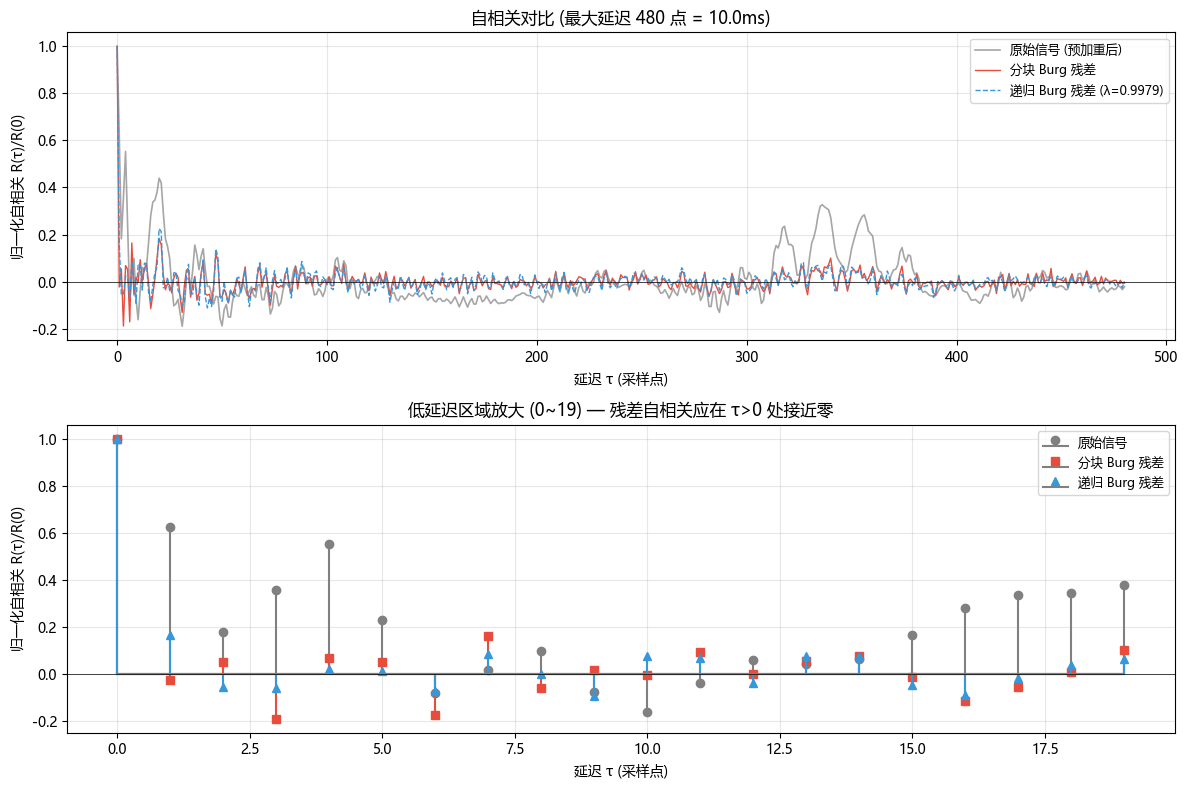

分块 Burg 残差 |R(τ>0)/R(0)| 最大值: 0.188682
递归 Burg 残差 |R(τ>0)/R(0)| 最大值: 0.225189
原始信号 |R(τ>0)/R(0)| 最大值: 0.623870


In [39]:
# ------------------------------------------------------------
# 自相关对比：原始信号 vs LPC 残差
# ------------------------------------------------------------
max_lag = int(0.010 * fs)  # 最大延迟 10ms（@48kHz = 480 采样点）

def normalized_autocorr(signal, max_lag):
    """计算归一化自相关 R[τ] / R[0]"""
    result = np.correlate(signal, signal, mode='full')
    mid = len(result) // 2
    r = result[mid:mid + max_lag + 1]
    return r / r[0]  # 归一化到 R[0]=1

r_x = normalized_autocorr(x_pre, max_lag)
r_e_block = normalized_autocorr(e_block_norm, max_lag)
r_e_rec = normalized_autocorr(e_rec_norm, max_lag)

lags = np.arange(max_lag + 1)

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# ===== 子图 1: 自相关全览 =====
ax1 = axes[0]
ax1.plot(lags, r_x, color='gray', linewidth=1.2, alpha=0.7, label='原始信号 (预加重后)')
ax1.plot(lags, r_e_block, color='#e74c3c', linewidth=1.0, label=f'分块 Burg 残差')
ax1.plot(lags, r_e_rec, color='#3498db', linewidth=1.0, linestyle='--', label=f'递归 Burg 残差 (λ={lam:.4f})')
ax1.axhline(y=0, color='black', linewidth=0.5)
ax1.set_xlabel('延迟 τ (采样点)')
ax1.set_ylabel('归一化自相关 R(τ)/R(0)')
ax1.set_title(f'自相关对比 (最大延迟 {max_lag} 点 = {max_lag/fs*1000:.1f}ms)')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# ===== 子图 2: 放大低延迟区域 (0~P) =====
ax2 = axes[1]
zoom_lag = P + 4  # 比阶数稍多
ax2.stem(lags[:zoom_lag], r_x[:zoom_lag], linefmt='gray', markerfmt='o',
         basefmt='gray', label='原始信号')
ax2.stem(lags[:zoom_lag], r_e_block[:zoom_lag], linefmt='#e74c3c', markerfmt='s',
         basefmt='gray', label='分块 Burg 残差')
ax2.stem(lags[:zoom_lag], r_e_rec[:zoom_lag], linefmt='#3498db', markerfmt='^',
         basefmt='gray', label='递归 Burg 残差')
ax2.axhline(y=0, color='black', linewidth=0.5)
ax2.set_xlabel('延迟 τ (采样点)')
ax2.set_ylabel('归一化自相关 R(τ)/R(0)')
ax2.set_title(f'低延迟区域放大 (0~{zoom_lag-1}) — 残差自相关应在 τ>0 处接近零')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 定量：非零延迟处残差自相关的最大绝对值
max_side_block = np.max(np.abs(r_e_block[1:]))
max_side_rec = np.max(np.abs(r_e_rec[1:]))
print(f"分块 Burg 残差 |R(τ>0)/R(0)| 最大值: {max_side_block:.6f}")
print(f"递归 Burg 残差 |R(τ>0)/R(0)| 最大值: {max_side_rec:.6f}")
print(f"原始信号 |R(τ>0)/R(0)| 最大值: {np.max(np.abs(r_x[1:])):.6f}")

In [26]:
# ------------------------------------------------------------
# 定量对比：系数误差与残差能量
# ------------------------------------------------------------
# LPC 系数误差（以分块 Burg 为参考）
coeff_error = np.sqrt(np.sum((a_block - a_rec)**2))
print(f"LPC 系数 RMS 误差: {coeff_error:.6e}")

# 残差能量
energy_block_total = np.sum(e_block**2)
energy_rec_total = np.sum(e_rec**2)
print(f"分块 Burg 残差能量: {energy_block_total:.6f}")
print(f"递归 Burg 残差能量: {energy_rec_total:.6f}")
print(f"能量比 (递归/分块): {energy_rec_total / energy_block_total:.4f}")

# 残差互相关
cross_corr = np.correlate(e_block, e_rec, mode='valid')[0]
norm_factor = np.sqrt(energy_block_total * energy_rec_total)
print(f"残差互相关系数: {cross_corr / norm_factor:.6f}")

LPC 系数 RMS 误差: 1.534826e+01
分块 Burg 残差能量: 0.016674
递归 Burg 残差能量: 0.021909
能量比 (递归/分块): 1.3140
残差互相关系数: 0.708506


# 全音频处理对比

将 `wormhole.wav` 整段音频分别用两种方法处理，观察全时长下的 LPC 包络谱与残差。

**分块 Burg**：30ms 帧长，10ms 帧移，每帧独立计算 LPC  
**递归 Burg**：逐样本递推，遗忘时间沿用 τ = 10ms

In [32]:
# ------------------------------------------------------------
# 加载全音频并预加重
# ------------------------------------------------------------
x_full_mono = x_full.copy()
if x_full_mono.ndim > 1:
    x_full_mono = x_full_mono[:, 0]

x_full_pre = np.append(x_full_mono[0], x_full_mono[1:] - pre_emph * x_full_mono[:-1])
t_full = np.arange(len(x_full_mono)) / fs

print(f"全长: {len(x_full_mono)} 样本 ({len(x_full_mono)/fs:.2f} 秒)")

全长: 458803 样本 (9.56 秒)


In [34]:
# ------------------------------------------------------------
# 分块 Burg：逐帧处理全音频
# ------------------------------------------------------------
frame_ms = 30         # 帧长 (ms)
hop_ms = 10           # 帧移 (ms)
frame_len = int(frame_ms * fs / 1000)   # 1440 @ 48kHz
hop_len = int(hop_ms * fs / 1000)       # 480

# 计算帧数
num_frames = 1 + (len(x_full_pre) - frame_len) // hop_len

# 存储每帧的 LPC 包络频谱（dB 谱矩阵）
n_fft_env = 1024
n_freqs = n_fft_env // 2 + 1
spec_block_env = np.zeros((num_frames, n_freqs))
e_block_full = np.zeros(len(x_full_pre))

# 汉宁窗（减少帧边界效应）
win = np.hanning(frame_len)

for idx in range(num_frames):
    start = idx * hop_len
    frame = x_full_pre[start:start + frame_len] * win
    a_frame, e_frame, _ = block_burg(frame, P)

    # LPC 包络（只取正频率：0~fs/2 共 n_freqs 个点）
    w_env, h_env = freqz(1.0, a_frame, worN=n_freqs, fs=fs)
    spec_block_env[idx] = 20.0 * np.log10(np.abs(h_env) + 1e-30)

    # 残差（OLA 拼接）
    e_block_full[start:start + frame_len] += e_frame * win

# 时间轴（每帧中心时刻）
t_frames = (np.arange(num_frames) * hop_len + frame_len / 2) / fs
freq_axis = w_env  # freqz 返回的频率轴

print(f"帧数: {num_frames}, 帧长: {frame_len}, 帧移: {hop_len}")

帧数: 953, 帧长: 1440, 帧移: 480


In [36]:
# ------------------------------------------------------------
# 递归 Burg：逐样本处理全音频
# ------------------------------------------------------------
# 重算递归 Burg（使用与前面相同的 lam）
a_rec_full, e_rec_full, k_history_full = recursive_burg(x_full_pre, P, lam=lam)

# 递归 Burg 的 LPC 包络谱：每 hop_len 采样取一帧
# 对递归法，反射系数随时间变化，因此 LPC 系数也随时间变化
rec_frame_indices = np.arange(0, len(x_full_pre), hop_len)
num_rec_frames = len(rec_frame_indices)
spec_rec_env = np.zeros((num_rec_frames, n_freqs))

for j, idx in enumerate(rec_frame_indices):
    # 从 k_history[idx] 计算 LPC 系数
    k_at_frame = k_history_full[idx]
    a_at_frame = np.ones(P + 1, dtype=np.float64)
    for m in range(P):
        k_m = k_at_frame[m]
        a_prev = a_at_frame.copy()
        a_at_frame[m + 1] = k_m
        for i in range(1, m + 1):
            a_at_frame[i] = a_prev[i] + k_m * a_prev[m - i + 1]

    w_env, h_env = freqz(1.0, a_at_frame, worN=n_freqs, fs=fs)
    spec_rec_env[j] = 20.0 * np.log10(np.abs(h_env) + 1e-30)

t_rec_frames = rec_frame_indices / fs

print(f"递归 Burg 包络帧数: {num_rec_frames}")
print(f"残差范围: [{e_rec_full.min():.4f}, {e_rec_full.max():.4f}]")

递归 Burg 包络帧数: 956
残差范围: [-0.0233, 0.0189]


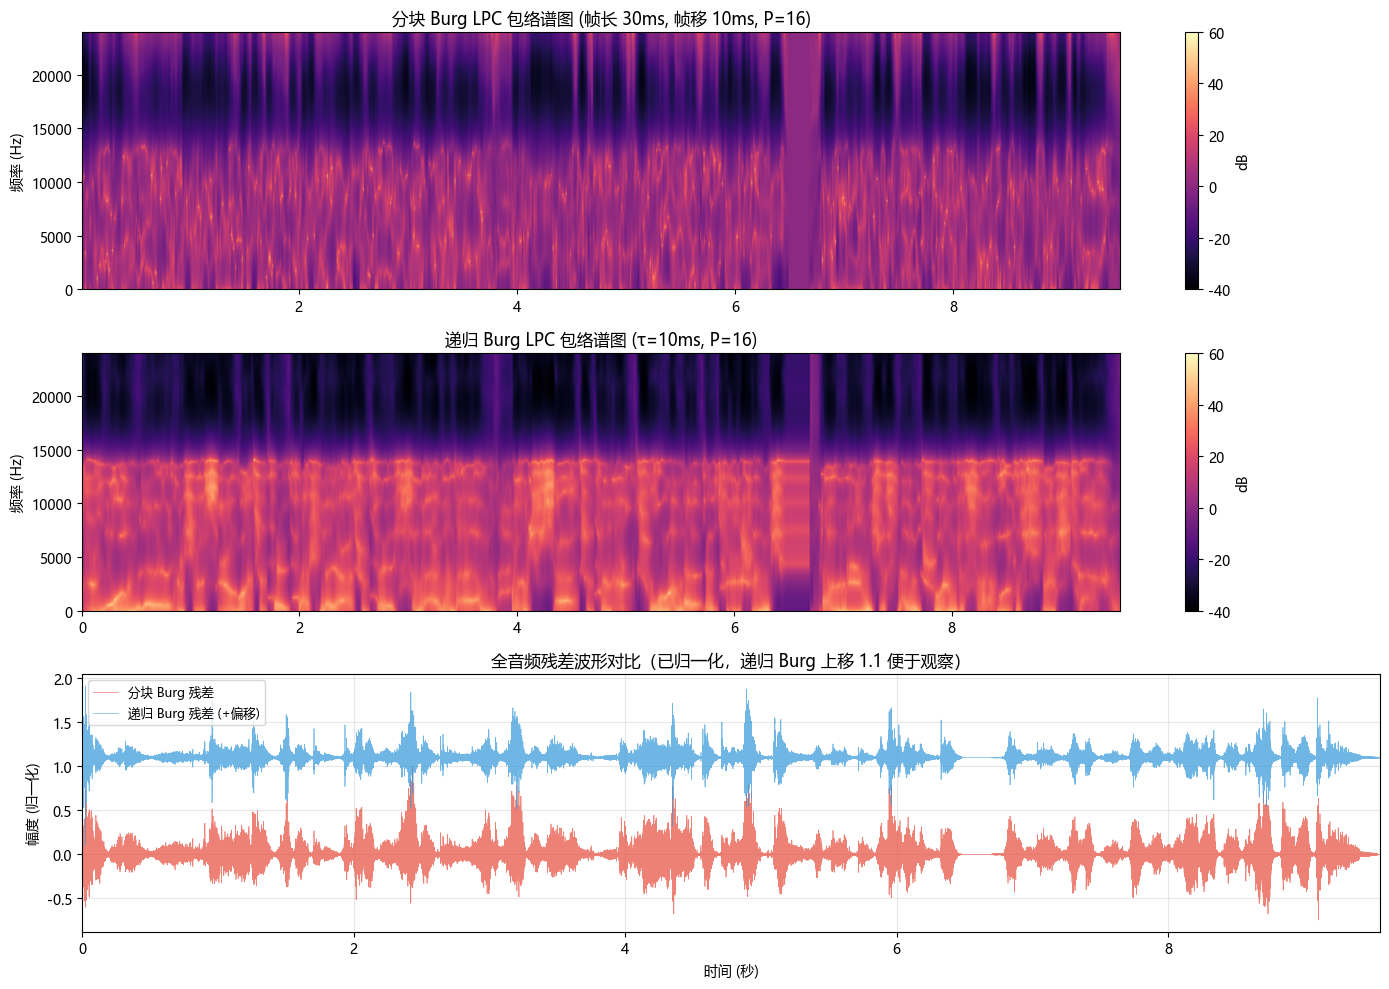

In [37]:
# ------------------------------------------------------------
# 绘图：LPC 包络谱图 + 残差波形（全音频）
# ------------------------------------------------------------
freq_axis = np.linspace(0, fs / 2, n_fft_env // 2 + 1)

fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# ===== 子图 1: 分块 Burg LPC 包络谱图 =====
ax1 = axes[0]
im1 = ax1.pcolormesh(t_frames, freq_axis, spec_block_env.T,
                     shading='gouraud', cmap='magma', vmin=-40, vmax=60)
ax1.set_ylabel('频率 (Hz)')
ax1.set_title(f'分块 Burg LPC 包络谱图 (帧长 {frame_ms}ms, 帧移 {hop_ms}ms, P={P})')
fig.colorbar(im1, ax=ax1, label='dB')

# ===== 子图 2: 递归 Burg LPC 包络谱图 =====
ax2 = axes[1]
im2 = ax2.pcolormesh(t_rec_frames, freq_axis, spec_rec_env.T,
                     shading='gouraud', cmap='magma', vmin=-40, vmax=60)
ax2.set_ylabel('频率 (Hz)')
ax2.set_title(f'递归 Burg LPC 包络谱图 (τ={tau*1000:.0f}ms, P={P})')
fig.colorbar(im2, ax=ax2, label='dB')

# ===== 子图 3: 残差波形对比 =====
ax3 = axes[2]
e_block_full_norm = e_block_full / (np.max(np.abs(e_block_full)) + 1e-30)
e_rec_full_norm = e_rec_full / (np.max(np.abs(e_rec_full)) + 1e-30)
ax3.plot(t_full, e_block_full_norm, color='#e74c3c', alpha=0.7, linewidth=0.5, label='分块 Burg 残差')
ax3.plot(t_full, e_rec_full_norm + 1.1, color='#3498db', alpha=0.7, linewidth=0.5, label='递归 Burg 残差 (+偏移)')
ax3.set_xlabel('时间 (秒)')
ax3.set_ylabel('幅度 (归一化)')
ax3.set_title('全音频残差波形对比（已归一化，递归 Burg 上移 1.1 便于观察）')
ax3.set_xlim(0, t_full[-1])
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [38]:
# ------------------------------------------------------------
# 全音频残差播放
# ------------------------------------------------------------
print("原始信号（全长）:")
display(Audio(x_full_mono, rate=fs))

print("分块 Burg 残差（全长，OLA 拼接后归一化）:")
display(Audio(e_block_full_norm, rate=fs))

print("递归 Burg 残差（全长，归一化后）:")
display(Audio(e_rec_full_norm, rate=fs))

原始信号（全长）:


分块 Burg 残差（全长，OLA 拼接后归一化）:


递归 Burg 残差（全长，归一化后）:
